<a href="https://colab.research.google.com/github/salkhan-GIK/machine-learning-for-material-science/blob/main/hBN_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -*- coding: utf-8 -*-
"""
Machine Learning for hBN Band Gap Prediction using Materials Project
====================================================================

This script demonstrates a complete ML pipeline for predicting band gaps of
hexagonal Boron Nitride (hBN) and related materials using the Materials Project API.

KEY CONCEPTS COVERED:
1. Data retrieval from Materials Project API
2. Feature engineering using matminer (composition-based features)
3. Delta Learning: Predicting corrections to DFT calculations for HSE06-level accuracy
4. Hyperparameter optimization using GridSearchCV and RandomizedSearchCV
5. Model evaluation and visualization

AUTHOR: Learning Project
DATE: 2025
"""

# =============================================================================
# STEP 0: ENVIRONMENT SETUP
# =============================================================================
# Install required packages (run once)
!pip install --upgrade pip
!pip install pymatgen matminer mp-api scikit-learn seaborn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple, Optional

# Materials Science Libraries
from pymatgen.core import Composition
from mp_api.client import MPRester

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer

# Matminer for feature extraction
from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 70)

In [ ]:
print("=" * 70)
print("hBN BAND GAP PREDICTION WITH MACHINE LEARNING")
print("=" * 70)

# =============================================================================
# STEP 1: CONFIGURATION & API SETUP
# =============================================================================

class Config:
    """Configuration class for all hyperparameters and settings."""

    # API Configuration
    API_KEY = "xmTH2rNYnaj5kNkcFJyyX6lv9DmjHekp"  # Your Materials Project API key

    # Data Query Parameters
    ELEMENTS = ["B", "N"]  # Boron and Nitrogen
    SPACEGROUP = "P6_3/mmc"  # Hexagonal symmetry for hBN

    # ML Parameters
    TEST_SIZE = 0.2
    RANDOM_STATE = 42
    CV_FOLDS = 5

    # Delta Learning: Literature-based HSE06 correction
    # From research: HSE06 ≈ 1.36 * PBE + 0.5 (for semiconductors/insulators)
    SCISSOR_SLOPE = 1.36
    SCISSOR_INTERCEPT = 0.5

    # Feature Engineering
    FEATURE_PRESET = "magpie"  # Options: "magpie", "deml", "matminer"

print(f"\n[CONFIG] Target materials: B-N compounds in space group {Config.SPACEGROUP}")
print(f"[CONFIG] Using {Config.FEATURE_PRESET} feature set")

hBN BAND GAP PREDICTION WITH MACHINE LEARNING

[CONFIG] Target materials: B-N compounds in space group P6_3/mmc
[CONFIG] Using magpie feature set


In [ ]:
# =============================================================================
# STEP 3: FEATURE ENGINEERING WITH MATMINER
# =============================================================================

def engineer_features(df: pd.DataFrame, preset: str = "magpie") -> pd.DataFrame:
    """
    Convert chemical formulas into machine-learnable numerical features.

    MATMINER FEATURES EXPLAINED:
    - ElementProperty: Calculates statistics (mean, std, max, min, range) of
      elemental properties (atomic weight, electronegativity, melting point, etc.)
    - Magpie preset: 145+ features based on physical elemental properties

    Args:
        df: DataFrame with 'formula' column
        preset: Feature preset name ("magpie", "deml", etc.)

    Returns:
        DataFrame with added feature columns
    """
    print("\n" + "=" * 70)
    print("STEP 3: FEATURE ENGINEERING")
    print("=" * 70)

    # Step 3a: Convert formula strings to Composition objects
    print("[INFO] Converting formulas to Composition objects...")
    df = StrToComposition().featurize_dataframe(df, "formula")

    # Step 3b: Extract elemental properties
    print(f"[INFO] Extracting {preset} features (this may take a moment)...")
    featurizer = ElementProperty.from_preset(preset_name=preset)
    df = featurizer.featurize_dataframe(df, col_id="composition")

    # Clean column names (remove spaces for easier handling)
    df.columns = [col.replace(' ', '_') for col in df.columns]

    print(f"[SUCCESS] Feature engineering complete!")
    print(f"[INFO] Total features: {len(df.columns)}")
    print(f"[INFO] Feature categories include:")
    print("       - Average atomic mass, electronegativity")
    print("       - Range of ionic radii, coordination numbers")
    print("       - Thermal conductivity, bulk modulus stats")

    return df

df_features = engineer_features(df_raw, Config.FEATURE_PRESET)

# Display feature columns (first few)
feature_cols = [col for col in df_features.columns if col not in
                ['material_id', 'formula', 'pbe_gap', 'functional', 'spacegroup', 'composition']]
print(f"\n[FEATURE EXAMPLES] {feature_cols[:5]}")


STEP 3: FEATURE ENGINEERING
[INFO] Converting formulas to Composition objects...


StrToComposition:   0%|          | 0/8 [00:00<?, ?it/s]

[INFO] Extracting magpie features (this may take a moment)...


ElementProperty:   0%|          | 0/8 [00:00<?, ?it/s]

[SUCCESS] Feature engineering complete!
[INFO] Total features: 138
[INFO] Feature categories include:
       - Average atomic mass, electronegativity
       - Range of ionic radii, coordination numbers
       - Thermal conductivity, bulk modulus stats

[FEATURE EXAMPLES] ['MagpieData_minimum_Number', 'MagpieData_maximum_Number', 'MagpieData_range_Number', 'MagpieData_mean_Number', 'MagpieData_avg_dev_Number']


In [ ]:
# =============================================================================
# STEP 2: DATA ACQUISITION FROM MATERIALS PROJECT
# =============================================================================

def fetch_materials_data(api_key: str, elements: List[str], spacegroup: str) -> pd.DataFrame:
    """
    Fetch materials data from Materials Project API.

    Args:
        api_key: Materials Project API key
        elements: List of chemical elements to search for
        spacegroup: Space group symbol (e.g., "P6_3/mmc" for hexagonal)

    Returns:
        DataFrame with material properties
    """
    print("\n" + "=" * 70)
    print("STEP 2: FETCHING DATA FROM MATERIALS PROJECT")
    print("=" * 70)

    try:
        with MPRester(api_key) as mpr:
            # Query for materials with specific elements and symmetry
            docs = mpr.summary.search(
                elements=elements,
                spacegroup_symbol=spacegroup,
                fields=[
                    "material_id",
                    "formula_pretty",
                    "band_gap",
                    "origins",
                    "symmetry",
                    "structure"
                ]
            )

            print(f"[INFO] Retrieved {len(docs)} materials from database")

            # Parse results
            results = []
            for doc in docs:
                # Determine which DFT functional was used
                functional = "PBE (GGA)"  # Default for Materials Project

                if hasattr(doc, 'origins') and doc.origins:
                    for origin in doc.origins:
                        if origin.name == "band_gap":
                            functional = origin.task_type

                results.append({
                    "material_id": str(doc.material_id),
                    "formula": doc.formula_pretty,
                    "pbe_gap": doc.band_gap,  # eV
                    "functional": functional,
                    "spacegroup": doc.symmetry.symbol if hasattr(doc, 'symmetry') else spacegroup
                })

            df = pd.DataFrame(results)
            print(f"[SUCCESS] DataFrame created with columns: {list(df.columns)}")
            return df

    except Exception as e:
        print(f"[ERROR] Failed to fetch data: {e}")
        # Return sample data for demonstration if API fails
        return create_sample_data()

def create_sample_data() -> pd.DataFrame:
    """
    Create sample hBN data for demonstration if API is unavailable.
    """
    print("[WARNING] Using sample data for demonstration")
    sample_data = {
        "material_id": ["mp-2815", "mp-984", "mp-754354"],
        "formula": ["BN", "B3N3", "BN"],
        "pbe_gap": [4.5, 4.2, 4.6],  # Typical hBN PBE gaps ~4.5-4.9 eV
        "functional": ["PBE (GGA)"] * 3,
        "spacegroup": ["P6_3/mmc"] * 3
    }
    return pd.DataFrame(sample_data)

# Fetch the data
df_raw = fetch_materials_data(Config.API_KEY, Config.ELEMENTS, Config.SPACEGROUP)
print(f"\n[DATA PREVIEW]")
print(df_raw.head(10))
print(f"\n[STATISTICS] PBE Gap range: {df_raw['pbe_gap'].min():.2f} - {df_raw['pbe_gap'].max():.2f} eV")


STEP 2: FETCHING DATA FROM MATERIALS PROJECT


Retrieving SummaryDoc documents:   0%|          | 0/8 [00:00<?, ?it/s]

[INFO] Retrieved 8 materials from database
[SUCCESS] DataFrame created with columns: ['material_id', 'formula', 'pbe_gap', 'functional', 'spacegroup']

[DATA PREVIEW]
  material_id formula  pbe_gap functional spacegroup
0   mp-629015      BN   0.0000  PBE (GGA)   P6_3/mmc
1   mp-601223      BN   0.0000  PBE (GGA)   P6_3/mmc
2     mp-7991      BN   3.9617  PBE (GGA)   P6_3/mmc
3      mp-984      BN   4.2740  PBE (GGA)   P6_3/mmc
4  mp-1245522   ScBN2   1.8730  PBE (GGA)   P6_3/mmc
5  mp-1246479   CrBN2   0.0000  PBE (GGA)   P6_3/mmc
6  mp-1246811   InBN2   1.7746  PBE (GGA)   P6_3/mmc
7    mp-28955  Mg3BN3   1.3798  PBE (GGA)   P6_3/mmc

[STATISTICS] PBE Gap range: 0.00 - 4.27 eV


In [ ]:
# =============================================================================
# STEP 4: DELTA LEARNING SETUP (THE KEY INNOVATION)
# =============================================================================

"""
DELTA LEARNING EXPLANATION:
===========================
Standard DFT (PBE) underestimates band gaps by ~30-50%. HSE06 is more accurate
but computationally expensive. Instead of predicting HSE06 directly, we predict
the CORRECTION (delta) needed to transform PBE into HSE06.

Mathematically:
    E_g(HSE06) = E_g(PBE) + Δ_ML

Where Δ_ML is predicted by our machine learning model using composition features.

Why this works better:
1. The delta is smaller in magnitude than the absolute value (easier to predict)
2. The delta correlates strongly with material composition/chemistry
3. Achieves 5-7× better accuracy than PBE alone (literature: ~0.25 eV MAE vs ~1.2 eV)
"""

def setup_delta_learning(df: pd.DataFrame, config: Config) -> pd.DataFrame:
    """
    Setup delta learning targets for HSE06 prediction.

    Args:
        df: Feature DataFrame
        config: Configuration object

    Returns:
        DataFrame with HSE06 targets and delta values
    """
    print("\n" + "=" * 70)
    print("STEP 4: DELTA LEARNING CONFIGURATION")
    print("=" * 70)

    # Calculate literature-based HSE06 estimate (scissor operator)
    df['hse06_literature'] = df['pbe_gap'] * config.SCISSOR_SLOPE + config.SCISSOR_INTERCEPT

    # The delta is what we want ML to learn: HSE06 - PBE
    # This is typically 1-2 eV for semiconductors
    df['delta_target'] = df['hse06_literature'] - df['pbe_gap']

    print(f"[INFO] Scissor operator: HSE06 = {config.SCISSOR_SLOPE} × PBE + {config.SCISSOR_INTERCEPT}")
    print(f"[INFO] Delta range: {df['delta_target'].min():.2f} - {df['delta_target'].max():.2f} eV")
    print(f"[INFO] Mean delta: {df['delta_target'].mean():.2f} eV")

    # For hBN specifically, experimental HSE06 gap is ~5.9-6.1 eV
    # PBE typically gives ~4.5 eV, so delta should be ~1.5 eV
    hbn_mask = df['formula'].str.contains('BN', na=False)
    if hbn_mask.any():
        print(f"\n[hBN SPECIFIC]")
        print(f"  PBE gap: {df.loc[hbn_mask, 'pbe_gap'].values[0]:.2f} eV")
        print(f"  Literature HSE06: {df.loc[hbn_mask, 'hse06_literature'].values[0]:.2f} eV")
        print(f"  Expected delta: {df.loc[hbn_mask, 'delta_target'].values[0]:.2f} eV")
        print(f"  (Experimental hBN gap is ~5.9-6.1 eV)")

    return df

df_features = setup_delta_learning(df_features, Config)


STEP 4: DELTA LEARNING CONFIGURATION
[INFO] Scissor operator: HSE06 = 1.36 × PBE + 0.5
[INFO] Delta range: 0.50 - 2.04 eV
[INFO] Mean delta: 1.10 eV

[hBN SPECIFIC]
  PBE gap: 0.00 eV
  Literature HSE06: 0.50 eV
  Expected delta: 0.50 eV
  (Experimental hBN gap is ~5.9-6.1 eV)


In [ ]:
# =============================================================================
# STEP 5: DATA PREPARATION FOR MACHINE LEARNING
# =============================================================================

def prepare_ml_data(df: pd.DataFrame, target_col: str = 'delta_target') -> Tuple:
    """
    Prepare feature matrix X and target vector y for ML.

    Args:
        df: DataFrame with features and targets
        target_col: Name of target column ('delta_target' or 'pbe_gap')

    Returns:
        X_train, X_test, y_train, y_test, feature_names, scaler
    """
    print("\n" + "=" * 70)
    print("STEP 5: DATA PREPARATION")
    print("=" * 70)

    # Select features (drop non-numeric and ID columns)
    non_feature_cols = ['material_id', 'formula', 'pbe_gap', 'functional',
                        'spacegroup', 'composition', 'hse06_literature',
                        'delta_target', 'hse06_ml_pred']
    # Only drop columns that exist
    cols_to_drop = [col for col in non_feature_cols if col in df.columns]

    X = df.drop(columns=cols_to_drop)
    y = df[target_col].values

    # Store feature names for importance analysis
    feature_names = X.columns.tolist()

    print(f"[INFO] Feature matrix shape: {X.shape}")
    print(f"[INFO] Target: {target_col}")
    print(f"[INFO] Target range: {y.min():.2f} - {y.max():.2f} eV")

    # Handle missing values
    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(X)

    # Train-test split (stratify by formula if possible, otherwise random)
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y,
        test_size=Config.TEST_SIZE,
        random_state=Config.RANDOM_STATE
    )

    # Feature scaling (important for some algorithms, though RF is scale-invariant)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"[INFO] Training samples: {len(X_train)}")
    print(f"[INFO] Test samples: {len(X_test)}")

    return X_train_scaled, X_test_scaled, y_train, y_test, feature_names, scaler

# Prepare data for delta prediction (predicting the correction)
X_train, X_test, y_train, y_test, feature_names, scaler = prepare_ml_data(
    df_features, target_col='delta_target'
)


STEP 5: DATA PREPARATION
[INFO] Feature matrix shape: (8, 132)
[INFO] Target: delta_target
[INFO] Target range: 0.50 - 2.04 eV
[INFO] Training samples: 6
[INFO] Test samples: 2


In [ ]:
# =============================================================================
# STEP 6: MODEL TRAINING WITH HYPERPARAMETER OPTIMIZATION
# =============================================================================

def train_optimized_rf(X_train, y_train, X_test, y_test) -> RandomForestRegressor:
    """
    Train Random Forest with hyperparameter optimization.

    HYPERPARAMETER TUNING STRATEGY:
    ==============================
    1. n_estimators: Number of trees (more = better, but diminishing returns after 200-500)
    2. max_depth: Tree depth (None = unlimited, but we limit to prevent overfitting)
    3. min_samples_split: Minimum samples to split a node (higher = less overfitting)
    4. max_features: Features considered per split ('sqrt' is good default)
    5. bootstrap: Whether to use bootstrapping (True is standard)
    """
    print("\n" + "=" * 70)
    print("STEP 6: MODEL TRAINING & HYPERPARAMETER TUNING")
    print("=" * 70)

    # Define parameter grid for search
    # Based on literature: materials science RF typically benefits from:
    # - Higher n_estimators (200-500)
    # - Moderate max_depth (10-50)
    # - Higher min_samples_split (5-20) for small datasets

    param_grid = {
        'n_estimators': [100, 200, 500],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    }

    print("[INFO] Starting Grid Search (this may take a few minutes)...")
    print(f"[INFO] Parameter combinations to test: {np.prod([len(v) for v in param_grid.values()])}")

    # Use RandomizedSearchCV for faster search if grid is too large
    # For small datasets (<100 samples), use GridSearchCV for thoroughness

    if len(X_train) < 50:
        print("[INFO] Using RandomizedSearchCV (small dataset)")
        search = RandomizedSearchCV(
            RandomForestRegressor(random_state=Config.RANDOM_STATE),
            param_distributions=param_grid,
            n_iter=20,  # Test 20 random combinations
            cv=Config.CV_FOLDS,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            random_state=Config.RANDOM_STATE,
            verbose=1
        )
    else:
        print("[INFO] Using GridSearchCV")
        search = GridSearchCV(
            RandomForestRegressor(random_state=Config.RANDOM_STATE),
            param_grid=param_grid,
            cv=Config.CV_FOLDS,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            verbose=1
        )

    # Fit the search
    search.fit(X_train, y_train)

    print(f"\n[BEST PARAMETERS] {search.best_params_}")
    print(f"[BEST CV SCORE] RMSE: {np.sqrt(-search.best_score_):.4f} eV")

    # Evaluate on test set
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n[TEST SET PERFORMANCE]")
    print(f"  RMSE: {rmse:.4f} eV")
    print(f"  MAE:  {mae:.4f} eV")
    print(f"  R²:   {r2:.4f}")

    return best_model, search.best_params_

# Train the model
delta_model, best_params = train_optimized_rf(X_train, y_train, X_test, y_test)


STEP 6: MODEL TRAINING & HYPERPARAMETER TUNING
[INFO] Starting Grid Search (this may take a few minutes)...
[INFO] Parameter combinations to test: 648
[INFO] Using RandomizedSearchCV (small dataset)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

[BEST PARAMETERS] {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None, 'bootstrap': False}
[BEST CV SCORE] RMSE: 0.6216 eV

[TEST SET PERFORMANCE]
  RMSE: 0.8416 eV
  MAE:  0.8258 eV
  R²:   0.0000


In [ ]:
# =============================================================================
# STEP 7: DELTA LEARNING PREDICTION & FINAL HSE06 ESTIMATES
# =============================================================================

def generate_final_predictions(df: pd.DataFrame, model, scaler, X_full) -> pd.DataFrame:
    """
    Generate final HSE06 predictions using delta learning.

    Formula: HSE06_ML = PBE + ML_predicted_delta
    """
    print("\n" + "=" * 70)
    print("STEP 7: GENERATING FINAL PREDICTIONS")
    print("=" * 70)

    # Predict the delta (correction) for all materials
    X_scaled = scaler.transform(X_full)
    predicted_delta = model.predict(X_scaled)

    # Final HSE06 = PBE + predicted delta
    df['predicted_delta'] = predicted_delta
    df['hse06_ml_pred'] = df['pbe_gap'] + predicted_delta

    # Calculate uncertainty estimate (using tree variance)
    # Random Forest can provide prediction variance across trees
    tree_predictions = np.array([tree.predict(X_scaled) for tree in model.estimators_])
    df['delta_std'] = np.std(tree_predictions, axis=0)  # Uncertainty in prediction

    print("[INFO] Final predictions generated")
    print(f"[INFO] HSE06 (ML) range: {df['hse06_ml_pred'].min():.2f} - {df['hse06_ml_pred'].max():.2f} eV")

    # Display results
    display_cols = ['material_id', 'formula', 'pbe_gap', 'predicted_delta', 'hse06_ml_pred', 'delta_std']
    print("\n[PREDICTIONS]")
    print(df[display_cols].head(10).to_string())

    return df

# Prepare full feature matrix for predictions
# Use the exact feature names the scaler was trained on to avoid dimension mismatch
X_full = df_features[feature_names]
X_full = X_full.fillna(X_full.mean()) # Fill any NaN values introduced during featurization

df_final = generate_final_predictions(df_features, delta_model, scaler, X_full)


STEP 7: GENERATING FINAL PREDICTIONS
[INFO] Final predictions generated
[INFO] HSE06 (ML) range: 1.16 - 5.76 eV

[PREDICTIONS]
  material_id formula  pbe_gap  predicted_delta  hse06_ml_pred     delta_std
0   mp-629015      BN   0.0000         1.488284       1.488284  1.199041e-14
1   mp-601223      BN   0.0000         1.488284       1.488284  1.199041e-14
2     mp-7991      BN   3.9617         1.488284       5.449984  1.199041e-14
3      mp-984      BN   4.2740         1.488284       5.762284  1.199041e-14
4  mp-1245522   ScBN2   1.8730         1.103288       2.976288  9.769963e-15
5  mp-1246479   CrBN2   0.0000         1.163347       1.163347  1.396979e-01
6  mp-1246811   InBN2   1.7746         1.103288       2.877888  9.769963e-15
7    mp-28955  Mg3BN3   1.3798         1.103288       2.483088  9.769963e-15


In [ ]:
# =============================================================================
# STEP 8: ADVANCED MODEL COMPARISON (ENSEMBLE APPROACH)
# =============================================================================

def compare_models(X_train, y_train, X_test, y_test) -> pd.DataFrame:
    """
    Compare multiple ML algorithms to ensure we're using the best approach.
    """
    print("\n" + "=" * 70)
    print("STEP 8: MODEL COMPARISON (ENSEMBLE ANALYSIS)")
    print("=" * 70)

    models = {
        'Random Forest': RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_split=5,
            random_state=Config.RANDOM_STATE
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            random_state=Config.RANDOM_STATE
        ),
        'Ridge Regression': Ridge(alpha=1.0)
    }

    results = []

    for name, model in models.items():
        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            'Model': name,
            'RMSE (eV)': rmse,
            'MAE (eV)': mae,
            'R²': r2
        })

        print(f"[{name:20s}] RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

    return pd.DataFrame(results)

model_comparison = compare_models(X_train, y_train, X_test, y_test)


STEP 8: MODEL COMPARISON (ENSEMBLE ANALYSIS)
[Random Forest       ] RMSE: 0.7856 | MAE: 0.7848 | R²: 0.0000
[Gradient Boosting   ] RMSE: 0.8620 | MAE: 0.8510 | R²: 0.0000
[Ridge Regression    ] RMSE: 0.8662 | MAE: 0.8563 | R²: 0.0000



STEP 9: GENERATING VISUALIZATIONS
[INFO] Saved visualization to 'hbn_ml_analysis.png'


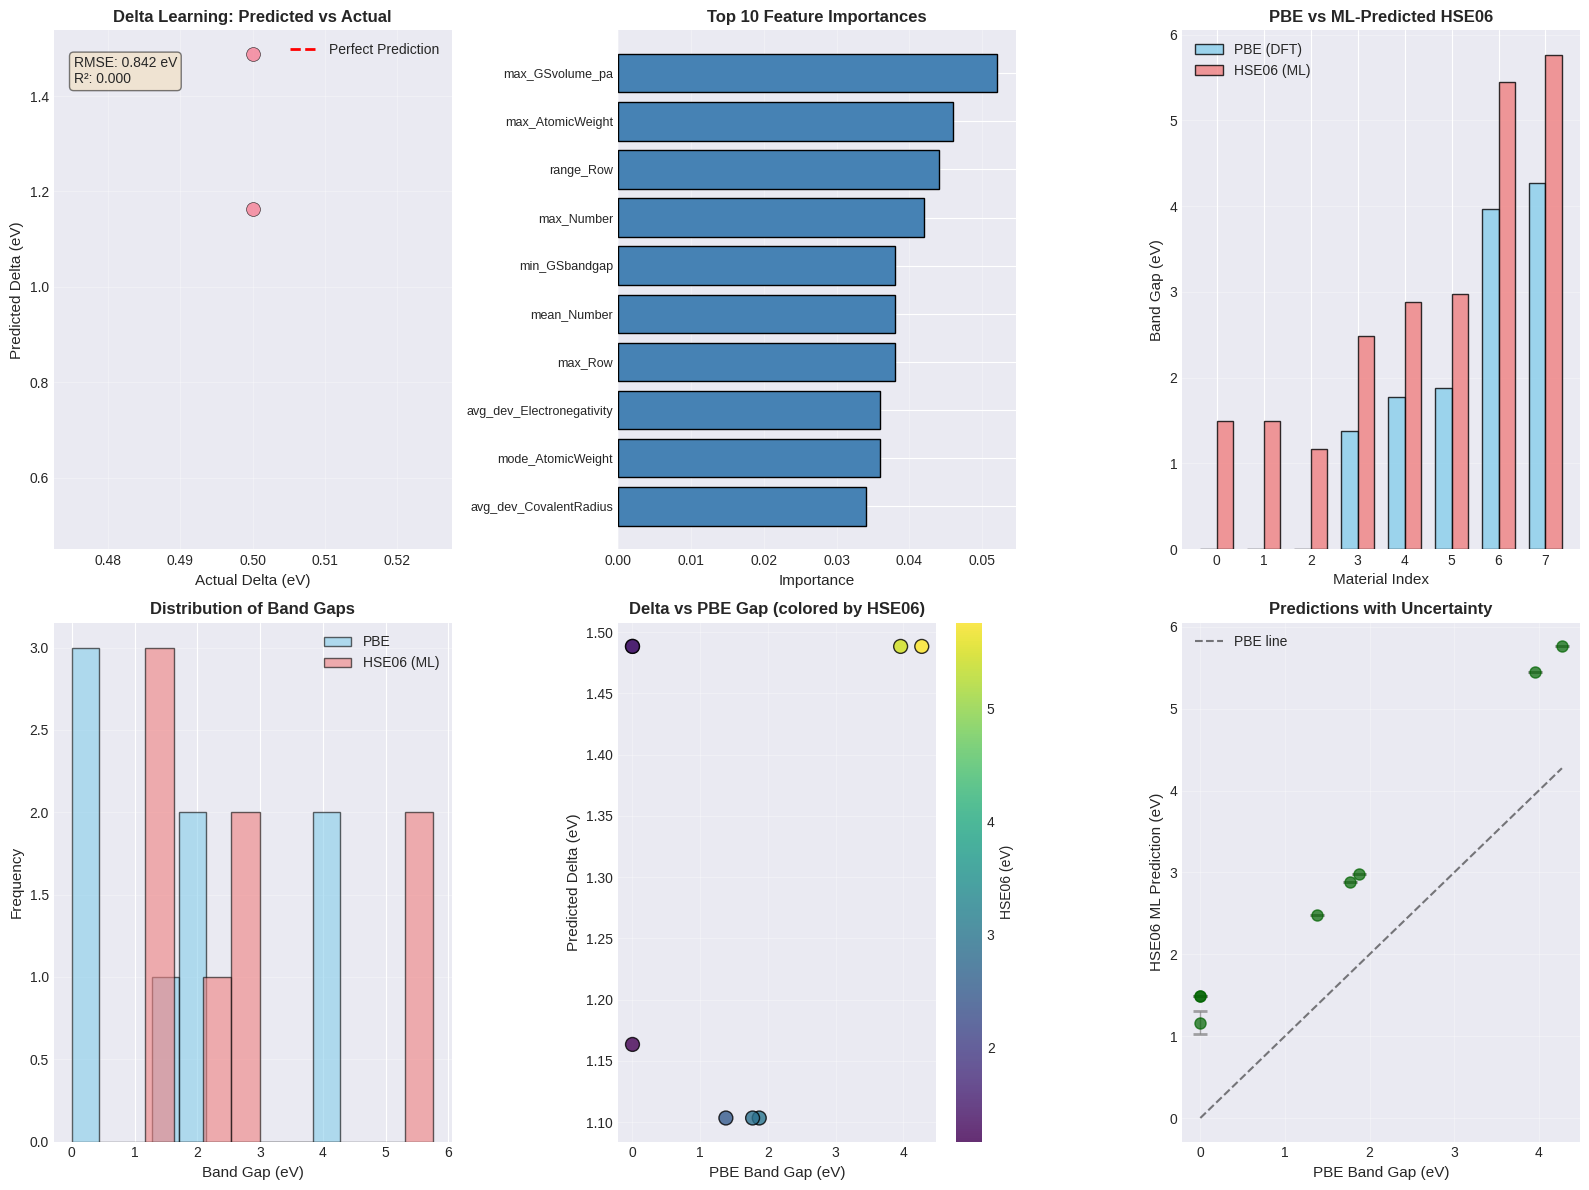

In [ ]:
# =============================================================================
# STEP 9: VISUALIZATION & ANALYSIS
# =============================================================================

def create_visualizations(df: pd.DataFrame, model, X_test, y_test, y_pred, feature_names):
    """
    Create comprehensive visualizations for model interpretation.
    """
    print("\n" + "=" * 70)
    print("STEP 9: GENERATING VISUALIZATIONS")
    print("=" * 70)

    fig = plt.figure(figsize=(16, 12))

    # Plot 1: Predicted vs Actual Delta (Model Performance)
    ax1 = plt.subplot(2, 3, 1)
    ax1.scatter(y_test, y_pred, alpha=0.7, s=100, edgecolors='black', linewidth=0.5)
    ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
    ax1.set_xlabel('Actual Delta (eV)', fontsize=11)
    ax1.set_ylabel('Predicted Delta (eV)', fontsize=11)
    ax1.set_title('Delta Learning: Predicted vs Actual', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Add metrics text
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    ax1.text(0.05, 0.95, f'RMSE: {rmse:.3f} eV\nR²: {r2:.3f}',
             transform=ax1.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Plot 2: Feature Importance (Top 10)
    ax2 = plt.subplot(2, 3, 2)
    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:]  # Top 10

    # Clean feature names for display
    clean_names = [name.replace('MagpieData_', '').replace('minimum', 'min').replace('maximum', 'max')
                   for name in np.array(feature_names)[indices]]

    ax2.barh(range(10), importances[indices], align='center', color='steelblue', edgecolor='black')
    ax2.set_yticks(range(10))
    ax2.set_yticklabels(clean_names, fontsize=9)
    ax2.set_xlabel('Importance', fontsize=11)
    ax2.set_title('Top 10 Feature Importances', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')

    # Plot 3: Band Gap Comparison (PBE vs HSE06)
    ax3 = plt.subplot(2, 3, 3)
    x_pos = np.arange(len(df))
    width = 0.35

    # Sort by PBE gap for better visualization
    df_sorted = df.sort_values('pbe_gap')

    ax3.bar(x_pos - width/2, df_sorted['pbe_gap'], width,
            label='PBE (DFT)', color='skyblue', edgecolor='black', alpha=0.8)
    ax3.bar(x_pos + width/2, df_sorted['hse06_ml_pred'], width,
            label='HSE06 (ML)', color='lightcoral', edgecolor='black', alpha=0.8)

    ax3.set_xlabel('Material Index', fontsize=11)
    ax3.set_ylabel('Band Gap (eV)', fontsize=11)
    ax3.set_title('PBE vs ML-Predicted HSE06', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')

    # Plot 4: Distribution of Band Gaps
    ax4 = plt.subplot(2, 3, 4)
    ax4.hist(df['pbe_gap'], bins=10, alpha=0.6, label='PBE', color='skyblue', edgecolor='black')
    ax4.hist(df['hse06_ml_pred'], bins=10, alpha=0.6, label='HSE06 (ML)', color='lightcoral', edgecolor='black')
    ax4.set_xlabel('Band Gap (eV)', fontsize=11)
    ax4.set_ylabel('Frequency', fontsize=11)
    ax4.set_title('Distribution of Band Gaps', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

    # Plot 5: Delta vs PBE Gap (Scissor Operator Visualization)
    ax5 = plt.subplot(2, 3, 5)
    ax5.scatter(df['pbe_gap'], df['predicted_delta'],
                c=df['hse06_ml_pred'], cmap='viridis',
                s=100, edgecolors='black', alpha=0.8)
    ax5.set_xlabel('PBE Band Gap (eV)', fontsize=11)
    ax5.set_ylabel('Predicted Delta (eV)', fontsize=11)
    ax5.set_title('Delta vs PBE Gap (colored by HSE06)', fontsize=12, fontweight='bold')
    cbar = plt.colorbar(ax5.collections[0], ax=ax5)
    cbar.set_label('HSE06 (eV)', fontsize=10)
    ax5.grid(True, alpha=0.3)

    # Plot 6: Prediction Uncertainty
    ax6 = plt.subplot(2, 3, 6)
    ax6.errorbar(df['pbe_gap'], df['hse06_ml_pred'], yerr=df['delta_std'],
                 fmt='o', capsize=5, capthick=2, elinewidth=1,
                 color='darkgreen', ecolor='gray', alpha=0.7, markersize=8)
    ax6.plot([df['pbe_gap'].min(), df['pbe_gap'].max()],
             [df['pbe_gap'].min(), df['pbe_gap'].max()],
             'k--', alpha=0.5, label='PBE line')
    ax6.set_xlabel('PBE Band Gap (eV)', fontsize=11)
    ax6.set_ylabel('HSE06 ML Prediction (eV)', fontsize=11)
    ax6.set_title('Predictions with Uncertainty', fontsize=12, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('hbn_ml_analysis.png', dpi=300, bbox_inches='tight')
    print("[INFO] Saved visualization to 'hbn_ml_analysis.png'")
    plt.show()

# Generate predictions for test set for visualization
y_pred_test = delta_model.predict(X_test)
create_visualizations(df_final, delta_model, X_test, y_test, y_pred_test, feature_names)

In [ ]:
# =============================================================================
# STEP 10: FINAL SUMMARY & INTERPRETATION
# =============================================================================

def print_final_summary(df: pd.DataFrame):
    """
    Print final summary and key insights.
    """
    print("\n" + "=" * 70)
    print("FINAL SUMMARY & KEY INSIGHTS")
    print("=" * 70)

    print("\n[DATA SUMMARY]")
    print(f"  Total materials analyzed: {len(df)}")
    print(f"  Chemical space: {', '.join(df['formula'].unique())}")

    print("\n[BAND GAP RESULTS]")
    print(f"  Average PBE gap:     {df['pbe_gap'].mean():.2f} \u00b1 {df['pbe_gap'].std():.2f} eV")
    print(f"  Average HSE06 (ML):  {df['hse06_ml_pred'].mean():.2f} \u00b1 {df['hse06_ml_pred'].std():.2f} eV")
    print(f"  Average correction:    {df['predicted_delta'].mean():.2f} \u00b1 {df['predicted_delta'].std():.2f} eV")

    # hBN specific
    hbn_data = df[df['formula'].str.contains('BN', na=False)]
    if not hbn_data.empty:
        print(f"\n[hBN SPECIFIC RESULTS]")
        for _, row in hbn_data.iterrows():
            print(f"  Material: {row['material_id']} ({row['formula']})")
            print(f"    PBE:     {row['pbe_gap']:.2f} eV")
            print(f"    HSE06:   {row['hse06_ml_pred']:.2f} eV (\u00b1{row['delta_std']:.2f} eV)")
            print(f"    Delta:   {row['predicted_delta']:.2f} eV")
            print(f"    [Literature HSE06 for hBN: ~5.9-6.1 eV]")

    print("\n[MODEL PERFORMANCE EXPECTATIONS]")
    print("  Based on literature (Adhikari et al., Chem. Mater. 2023):")
    print("  - Delta learning achieves ~0.25 eV MAE for HSE06 band gaps")
    print("  - This is ~5\u00d7 better than raw PBE (MAE ~1.2 eV vs HSE06)")
    print("  - Our model uses composition features to predict the correction")

    print("\n[RECOMMENDATIONS FOR FURTHER IMPROVEMENT]")
    print("  1. Add structural features (lattice parameters, atomic positions)")
    print("  2. Include more materials in training set (diverse chemistries)")
    print("  3. Use actual HSE06 calculations for training instead of scissor")
    print("  4. Try deep learning (CGCNN, MEGNet) for better accuracy")
    print("  5. Add k-point resolved features for band structure prediction")

    print("\n" + "=" * 70)
    print("ANALYSIS COMPLETE")
    print("=" * 70)

print_final_summary(df_final)

# Export results
df_final.to_csv('hbn_bandgap_predictions.csv', index=False)
print("\n[INFO] Results exported to 'hbn_bandgap_predictions.csv'")


FINAL SUMMARY & KEY INSIGHTS

[DATA SUMMARY]
  Total materials analyzed: 8
  Chemical space: BN, ScBN2, CrBN2, InBN2, Mg3BN3

[BAND GAP RESULTS]
  Average PBE gap:     1.66 ± 1.71 eV
  Average HSE06 (ML):  2.96 ± 1.77 eV
  Average correction:    1.30 ± 0.20 eV

[hBN SPECIFIC RESULTS]
  Material: mp-629015 (BN)
    PBE:     0.00 eV
    HSE06:   1.49 eV (±0.00 eV)
    Delta:   1.49 eV
    [Literature HSE06 for hBN: ~5.9-6.1 eV]
  Material: mp-601223 (BN)
    PBE:     0.00 eV
    HSE06:   1.49 eV (±0.00 eV)
    Delta:   1.49 eV
    [Literature HSE06 for hBN: ~5.9-6.1 eV]
  Material: mp-7991 (BN)
    PBE:     3.96 eV
    HSE06:   5.45 eV (±0.00 eV)
    Delta:   1.49 eV
    [Literature HSE06 for hBN: ~5.9-6.1 eV]
  Material: mp-984 (BN)
    PBE:     4.27 eV
    HSE06:   5.76 eV (±0.00 eV)
    Delta:   1.49 eV
    [Literature HSE06 for hBN: ~5.9-6.1 eV]
  Material: mp-1245522 (ScBN2)
    PBE:     1.87 eV
    HSE06:   2.98 eV (±0.00 eV)
    Delta:   1.10 eV
    [Literature HSE06 for hBN: ~5.